In [1]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/Homeworks


# Tarea 3: Aplicacion de test de raiz unitaria en Series de Tiempo

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from source.data.loaders import create_dataset
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.


### Cargando los datos

El archivo `base_25.xls` contiene informacion mensual de: 
- $Y$: IMACEC , 
- $P$: IPC  
- $I$ Tasa de Politica Monetaria 

Considere las series cuya `::key` asociada al diccionario de datos se muestra a continuacion
- `p`: $\ln(P_t)$, 
- `y`: $\ln(Y_t)$, 
- `dtp`: $\Delta \ln(P_t)$, 
- `dty`: $\Delta \ln(Y_t)$, 
- `i`: $i_t = I_t/100$.
- `t`: periodo $t$

In [3]:
dataset = create_dataset('./data/base_25.xls', problem=6)

[INFO] ¡Datos cargados exitosamente!


✅ Figura guardada exitosamente en ./presentation/figures/hw3/series_raw.pdf


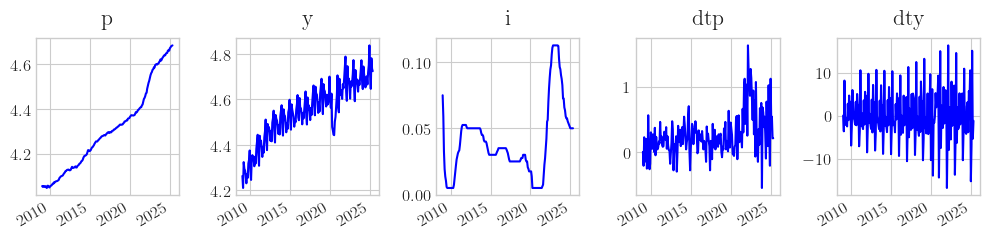

In [4]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=5, 
    figsize=(10, 2.5), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/series_raw.pdf')

## Test 1: DF (Dickey-Fuller)

In [5]:
df_se = {} 
df_se["p"] = testmodule.test_df(dataset["p"], estacionalizar = "si") 
df_se["y"] = testmodule.test_df(dataset["y"], estacionalizar = "si") 
df_se["i"] = testmodule.test_df(dataset["i"], estacionalizar = "si") 
df_se["dtp"] = testmodule.test_df(np.array(dataset["dtp"]), estacionalizar = "si") 
df_se["dty"] = testmodule.test_df(np.array(dataset["dty"]), estacionalizar = "si") 

df_ne = {} 
df_ne["p"] = testmodule.test_df(dataset["p"], estacionalizar = "no") 
df_ne["y"] = testmodule.test_df(dataset["y"], estacionalizar = "no") 
df_ne["i"] = testmodule.test_df(dataset["i"], estacionalizar = "no") 
df_ne["dtp"] = testmodule.test_df(np.array(dataset["dtp"]), estacionalizar = "no") 
df_ne["dty"] = testmodule.test_df(np.array(dataset["dty"]), estacionalizar = "no") 
df_ne['p']

,statistic,p-value
0,-0.693475,0.973573


## Test 2: ADF (Augmented Dickey-Fuller)

In [ ]:
testmodule.test_adf()

## Test 3: PP (Phillips-Perron)

In [6]:
testmodule.test_pp(dataset['dty'])

,model,statistic,p-value
0,Sin constante ni tendencia,-23.497269,0.01
1,Con constante,-23.702350,0.01
2,Con constante y tendencia,-23.635939,0.01


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [11]:
testmodule.test_kpss()

Test KPSS


## Test 5: Perron

In [97]:
%%time
test_results=[]
for lab in ['y', 'p', 'dtp', 'dty', 'i']:
    try:
        out = testmodule.test_perron(dataset[lab], parallel=True, varname=lab)
        out['variable'] = [lab]*out.shape[0]
        test_results.append(out)
    except Exception as e:
        print(e)
        continue

Test Perron


Test Perron
Test Perron
Test Perron
Test Perron
CPU times: user 690 ms, sys: 810 ms, total: 1.5 s
Wall time: 8min 55s


In [100]:
final = pd.concat(test_results, axis=0)

In [114]:
pd.DataFrame(dataset)

,p,y,i,dtp,dty,t
0,4.054765,4.262821,0.0749,0.000000,0.00,2009-01-01
1,4.051115,4.209903,0.0588,-0.210124,-3.66,2009-02-01
2,4.055029,4.323868,0.0327,0.225330,8.13,2009-03-01
3,4.053469,4.294561,0.0192,-0.089933,-2.18,2009-04-01
4,4.050965,4.287441,0.0136,-0.144039,-0.52,2009-05-01
...,...,...,...,...,...,...
192,4.670396,4.709440,0.0500,1.120000,-15.27,2025-01-01
193,4.674323,4.646792,0.0500,0.420000,-6.74,2025-02-01
194,4.679350,4.781725,0.0500,0.540000,15.06,2025-03-01
195,4.681298,4.735496,0.0500,0.210000,-5.39,2025-04-01


✅ Figura guardada exitosamente en ./presentation/figures/hw3/breakpoints.pdf


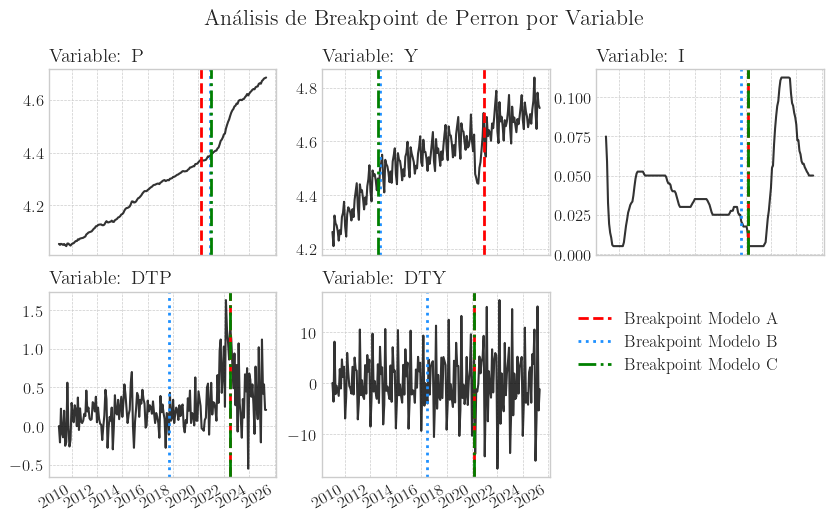

In [146]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=False)
axes = axes.flatten()
data_df = pd.DataFrame(dataset)
# 1. Asegúrate de que la columna de fecha sea del tipo datetime
data_df['t'] = pd.to_datetime(data_df['t'])

# 2. Establece esa columna como el índice del DataFrame
data_df.set_index('t', inplace=True)

fig, axes = plot_utils.plot_series_with_breakpoints( data_df,
                                        final,
                                        variables= ['p', 'y', 'i', 'dtp', 'dty'],
                                        fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/breakpoints.pdf')

Escala de color recortada al rango: [-7.44, -5.86]
Óptimo encontrado: HQC=-7.67 en p=33, breakpoint=134
✅ Figura guardada exitosamente en ./presentation/figures/hw3/best_p_model_a.pdf


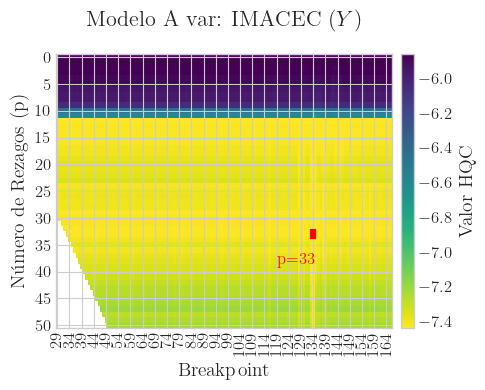

In [101]:
import glob, os, re
model = 'model_a/y/'
ruta_carpeta = './presentation/backup/perron/'+model
patron_busqueda = os.path.join(ruta_carpeta, "*.csv")
lista_archivos_csv = glob.glob(patron_busqueda)
regex = r'(\d+)(?=\.csv$)'
frames = []
for ruta_archivo in lista_archivos_csv:
    # re.search() busca el patrón en la cadena
    match = re.search(regex, ruta_archivo)
    if match:
        # El grupo 1 contiene el número capturado
        n = int(match.group(1))
        df_file = pd.read_csv(ruta_archivo)
        df_file['breakpoint'] = [n]*df_file.shape[0]
        frames.append(df_file)
frames = pd.concat(frames, axis=0)

matriz_hqc = frames.pivot_table(
    index='p', 
    columns='breakpoint', 
    values='HQC'
)

titles = {
    'model_a/y/': 'Modelo A var: IMACEC ($Y$)',
    'model_b/y/': 'Modelo B var: IMACEC ($Y$)',
    'model_c/y/': 'Modelo C var: IMACEC ($Y$)',

    'model_a/i/': 'Modelo A var: TPM $(i)$',
    'model_b/i/': 'Modelo B var: TPM $(i)$',
    'model_c/i/': 'Modelo C var: TPM $(i)$',

    'model_a/p/': 'Modelo A var: Inflacion $(P)$',
    'model_b/p/': 'Modelo B var: Inflacion $(P)$',
    'model_c/p/': 'Modelo C var: Inflacion $(P)$'
}
fig, ax = plt.subplots(1, 1, figsize=(5,4))
fig, ax = plot_utils.plot_hqc_heatmap(matriz_hqc, 
                                      fig=fig, 
                                      ax=ax, 
                                      title=titles[model], 
                                      quantile_clip=(0.05, 0.95))
save_figure(fig, './presentation/figures/hw3/best_p_{}.pdf'.format(model.split('/')[0]))

In [96]:

pd.concat(test_results, axis=0)

,model,break,pstar,statistic,p-value,variable
0,model_a,143,12,-4.115428,0.022144,y
0,model_b,45,12,-4.524029,0.010000,y
0,model_c,43,12,-4.562611,0.015080,y


## Test 6: Zivot-Andrews

In [13]:
testmodule.test_zivot_andrews()

Test Zivot-Andrews


## Test 7: Bierens

In [14]:
testmodule.test_bierens()

Test Bierens


## Test 8: Murray and Nelson

In [15]:
murray_nelson = {} 
murray_nelson["p"] = testmodule.test_murray_nelson(dataset["p"], periodos=[7,68,157], persistente=152) 
murray_nelson["y"] = testmodule.test_murray_nelson(dataset["y"], periodos=[25,145,155], persistente=135) 
murray_nelson["i"] = testmodule.test_murray_nelson(dataset["i"], periodos=[0,1,2], persistente=150) 
murray_nelson["dtp"] = testmodule.test_murray_nelson(np.array(dataset["dtp"]), periodos=[157,178,191], persistente=152) 
murray_nelson["dty"] = testmodule.test_murray_nelson(np.array(dataset["dty"]), periodos=[191,158,143,146,155]) 
murray_nelson["p"]

,statistic,p-value
0,-6.815129,3.685725e-08


## Test 9: GLS detrending

In [ ]:
testmodule.test_gls(dataset['p'],d=3,p=2,alpha=0.05)

,Parametro,Valor
0,Estadistico ADF-GLS,-0.2689
1,Valor critico (5%),-2.8900
2,p-valor (aproximado),0.3940
3,Decision,No rechazar H0
4,Interpretacion,La serie no es estacionaria
